In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import os
from pathlib import Path
import sys
import pandas as pd
import corner

import cogwheel.likelihood
import cogwheel.data
import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
import make_event_data
from parameter_estimation import get_chirp_mass, get_table_data, add_derived_quantities

In [3]:
# helper function to add a column to the df of posterior samples with the weights multiplied by the prior ratio
def add_reweights(samples, col_name):
    # reweight the posterior samples by the prior ratio of P(flat in luminosity volume)/P(flat in comoving volume)
    comov_dist_prior = cogwheel.likelihood.marginalization.lookup_table.comoving_distance_prior(samples['d_luminosity'].values)
    lumin_dist_prior = cogwheel.likelihood.marginalization.lookup_table.euclidean_distance_prior(samples['d_luminosity'].values)
    prior_ratio = comov_dist_prior / lumin_dist_prior
    samples[col_name] = samples['weights'] * prior_ratio

In [4]:
# helper function to get median values
def get_medians(samples, corner_plot):
    medians = {}
    for key in samples.keys():
        medians[key] = corner_plot._get_median_and_central_interval(key)[0]
    return medians

In [5]:
def load_posterior_samples(eventname, event_path):
    # find the "earliest" run with posterior samples
    i = 0
    while i < 10:
        try:
            samples = pd.read_feather(os.path.join(event_path, f'run_{i}', 'samples.feather'))
            print(f"loaded posterior samples for {eventname} run {i}")
            break
        except FileNotFoundError:
            i += 1

    # add derived quantities
    add_derived_quantities(samples)

    # load the posterior samples from the LIGO PE data release
    pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
    data = read(pe_data_fn)
    # get the posterior samples using the IMRPhenomXPHM approximant
    samples_lvk = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]

    return samples, samples_lvk

In [6]:
# load samples from event posterior(s)

# where we've saved the posteriors and samples
resdir = '../data/pe_runs/IntrinsicLVCPrior'

# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 13 events


In [12]:
# plot parameters for our cogwheel results:
plot_params = [
    'mchirp',
    'm1',
    'm2',
    'chieff',
    'd_luminosity',
    'ra',
    'dec'
]
# and for the LVK results
plot_params_lvk = [
    'chirp_mass',
    'mass_1',
    'mass_2',
    'chi_eff',
    'luminosity_distance',
    'ra',
    'dec'
]

In [13]:
# colors for plotting
c1 = '#1C00D1'
c2 = '#FF0000'
c3 = 'mediumseagreen'

# and custom legend
custom_lines = [Line2D([0], [0], color=c1, lw=4, alpha=0.6),
                    Line2D([0], [0], color=c3, lw=4, alpha=0.6),
                    Line2D([0], [0], color=c2, lw=4, alpha=0.6)]

loaded posterior samples for GW231226_101520 run 1
loaded posterior samples for GW240104_164932 run 0
loaded posterior samples for GW230914_111401 run 0
loaded posterior samples for GW231028_153006 run 0
loaded posterior samples for GW231206_233901 run 0
loaded posterior samples for GW230628_231200 run 0
loaded posterior samples for GW230518_125908 run 0


2026-01-01  20:30:31 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-01  20:30:31 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-01  20:30:32 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-01  20:30:32 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-01  20:30:32 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Currently only the IMRPhenomNSBH waveform model can be used. Unable to calculate the NSBH conversion
2026-01-01  20:30:32 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Current

loaded posterior samples for GW230927_153832 run 0
loaded posterior samples for GW231123_135430 run 1
loaded posterior samples for GW230627_015337 run 1
loaded posterior samples for GW230919_215712 run 0
loaded posterior samples for GW231102_071736 run 0
loaded posterior samples for GW230814_230901 run 0


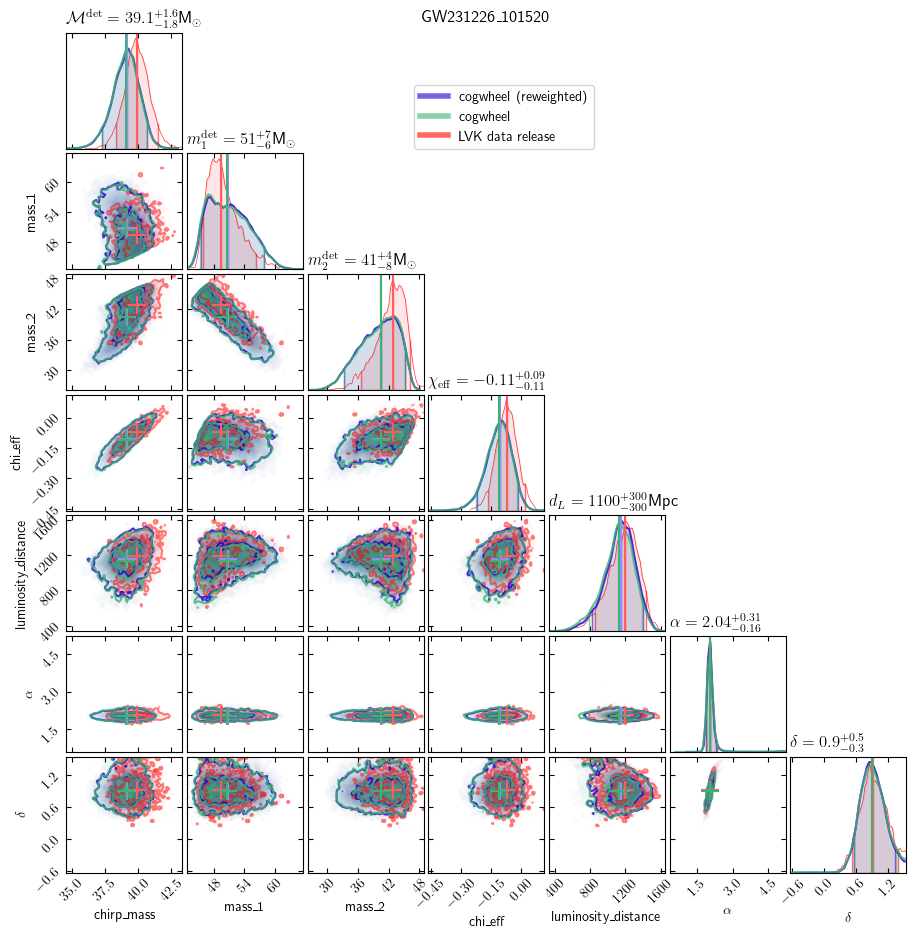

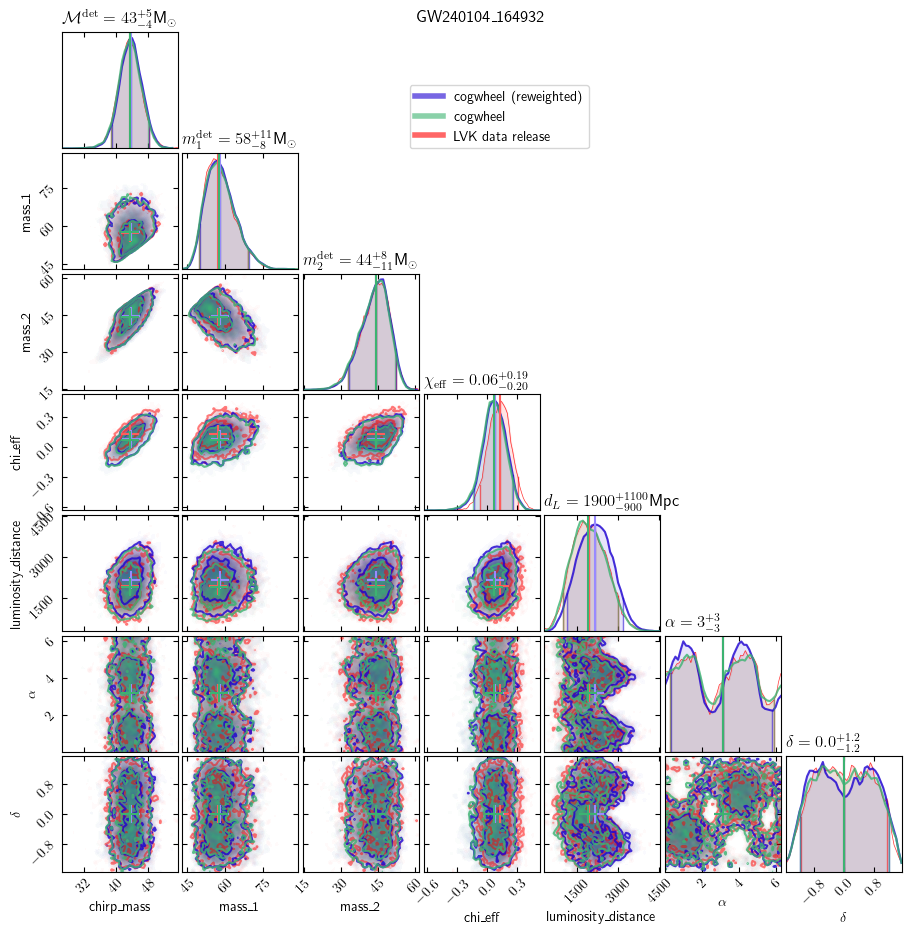

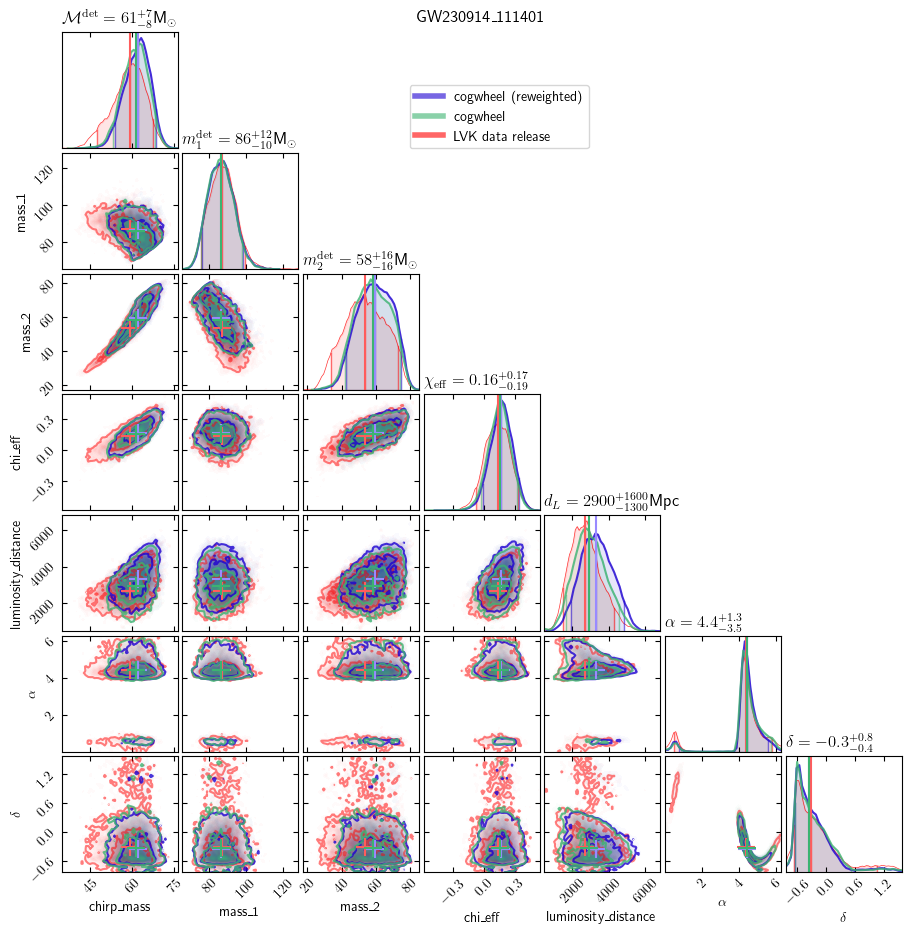

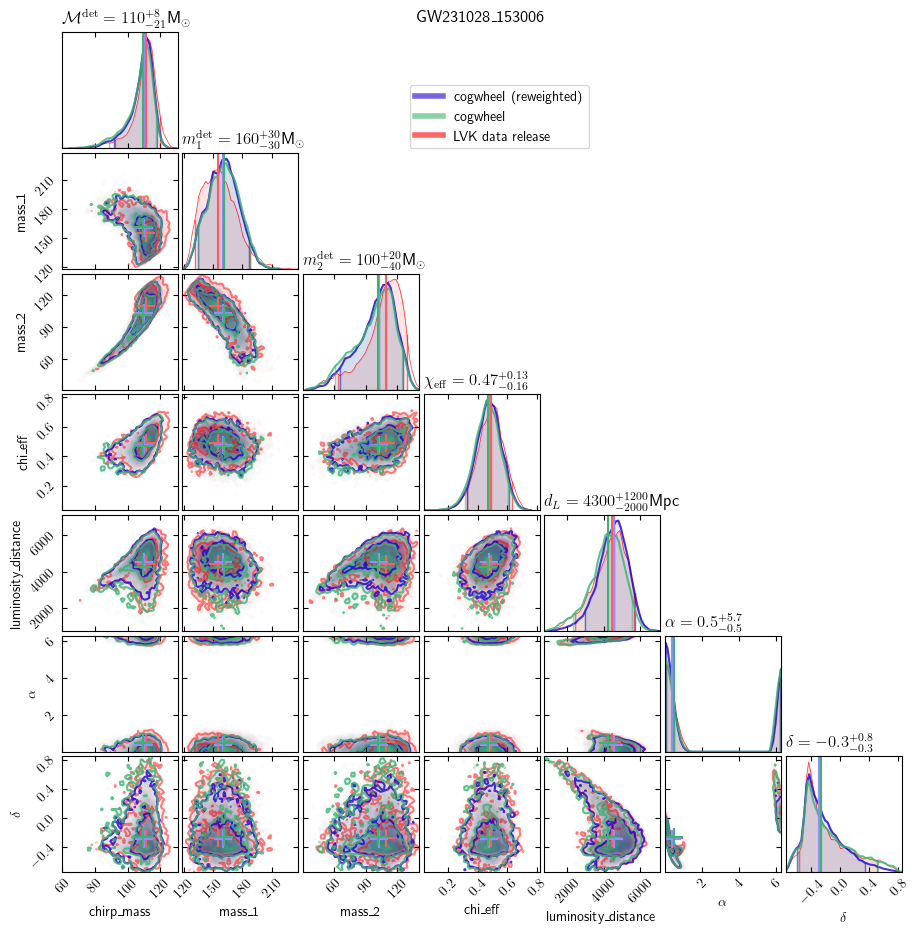

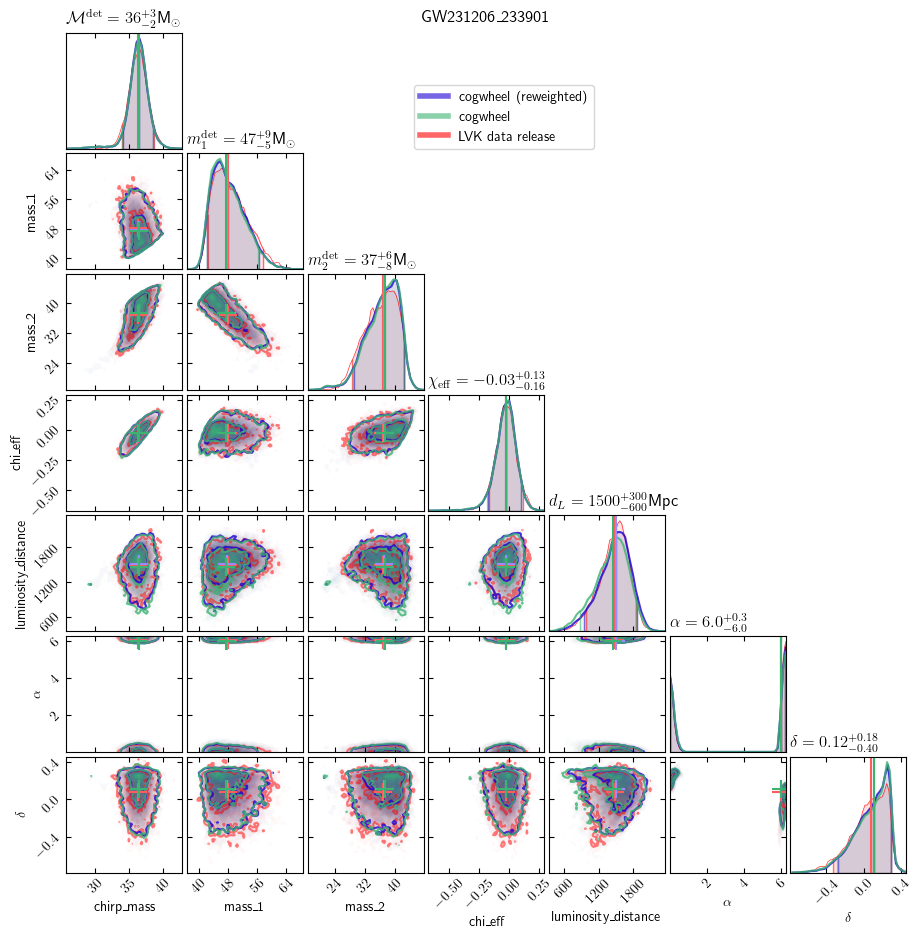

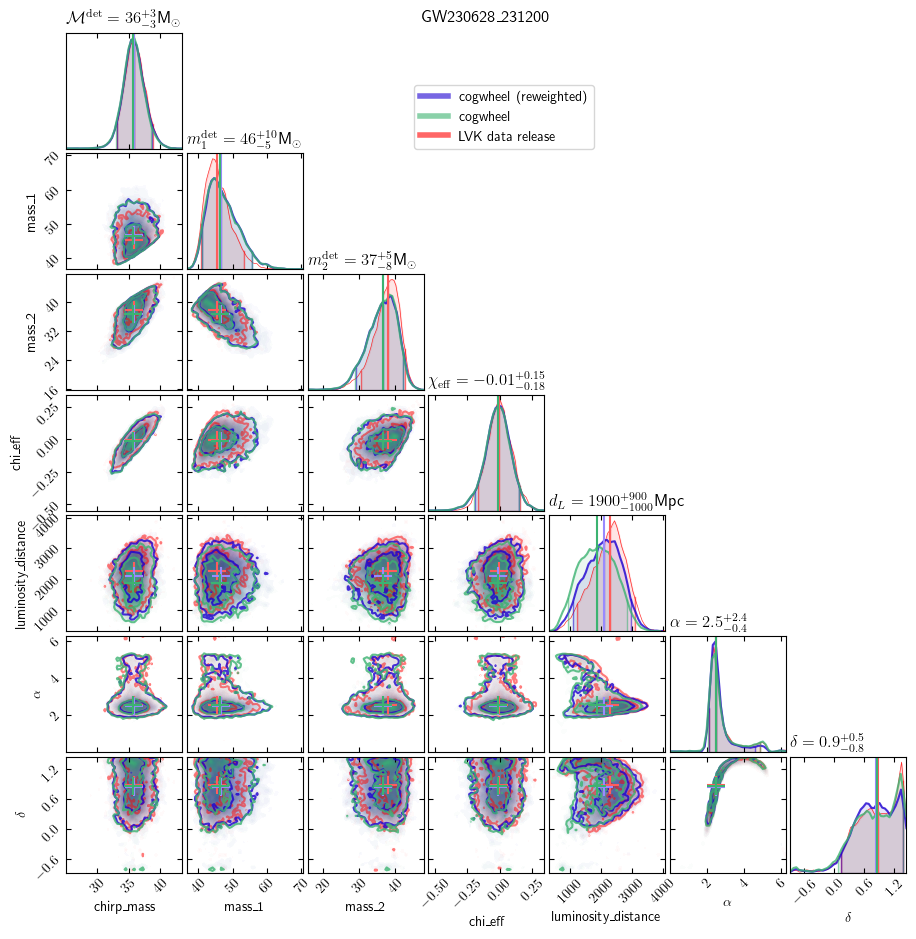

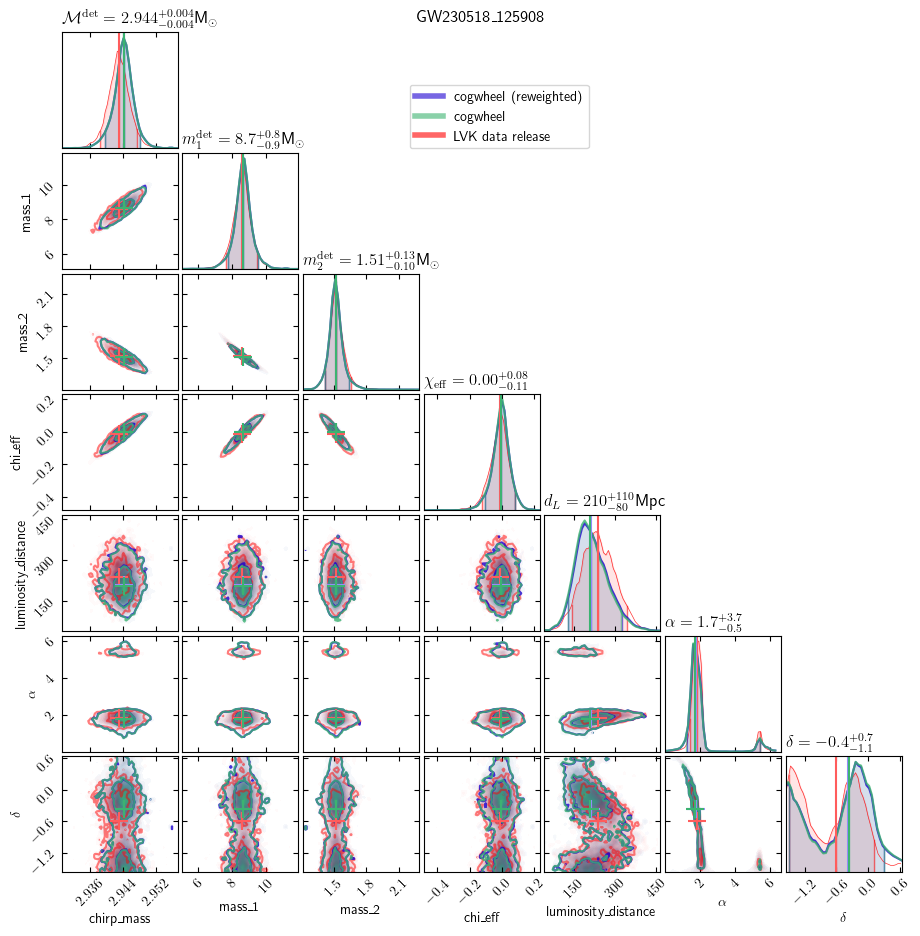

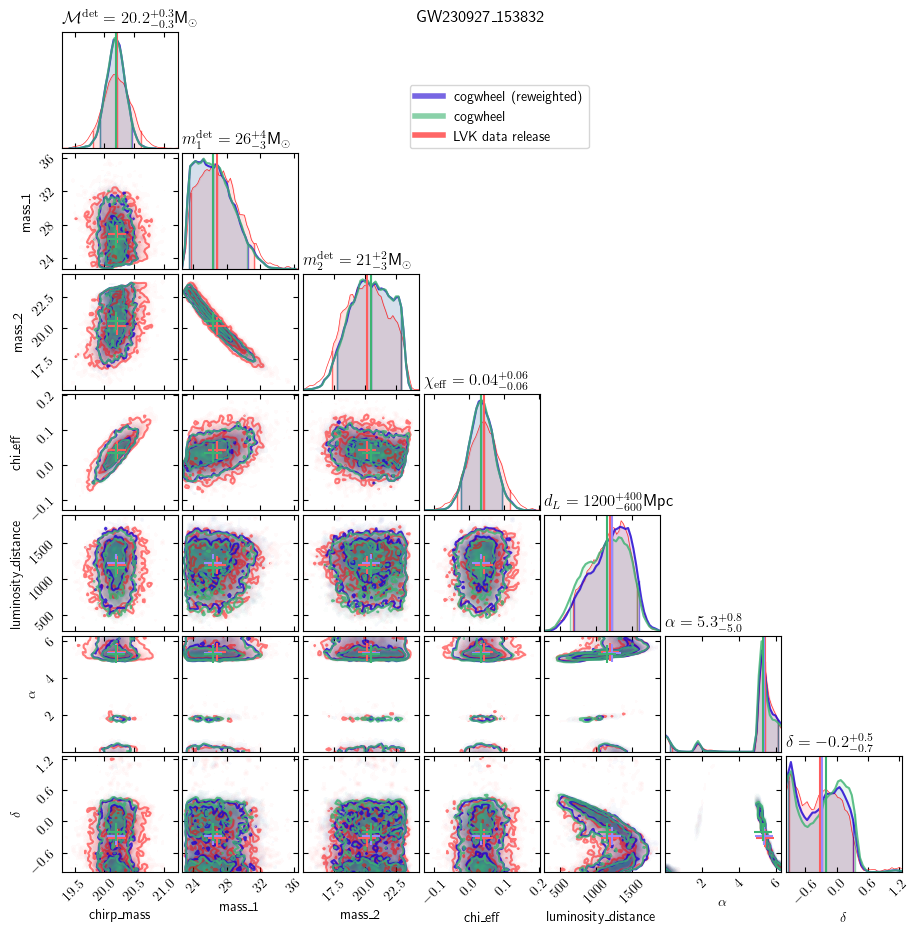

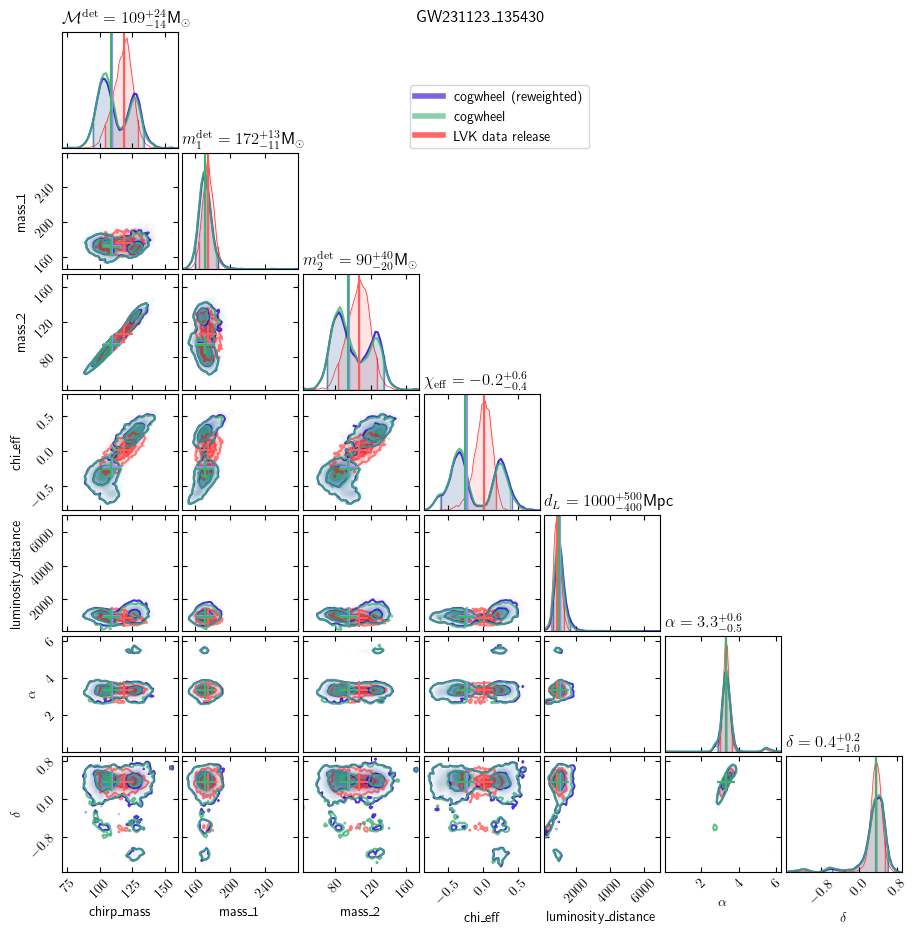

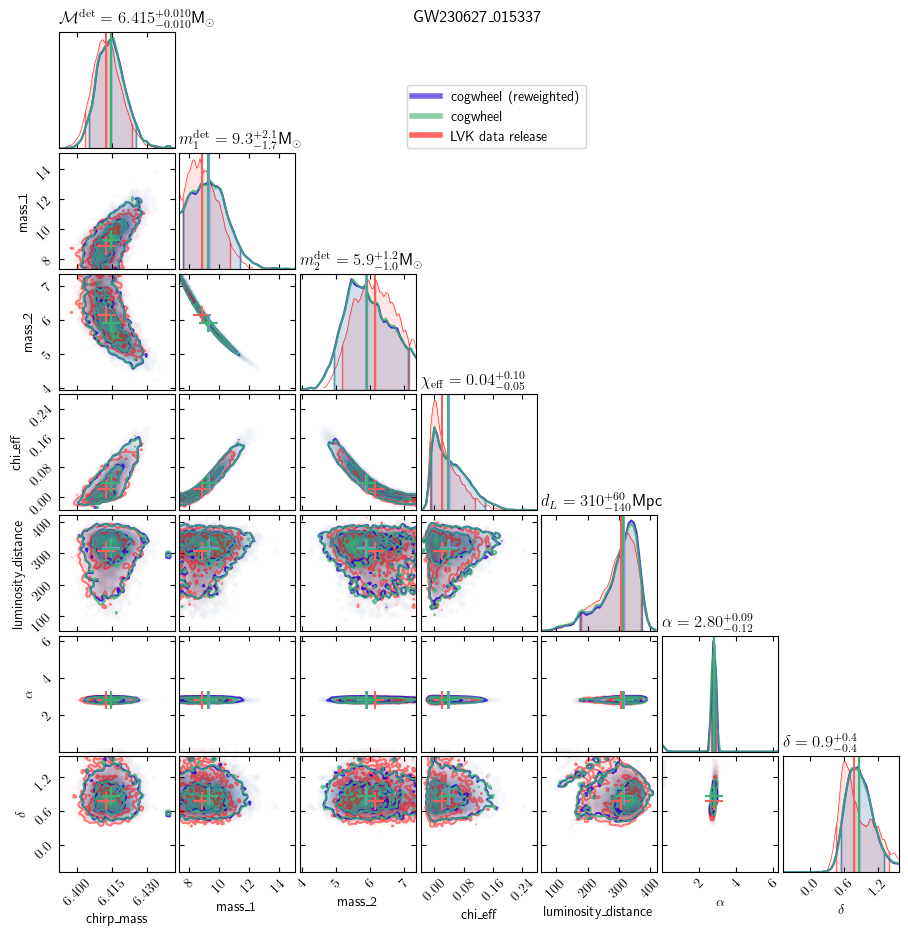

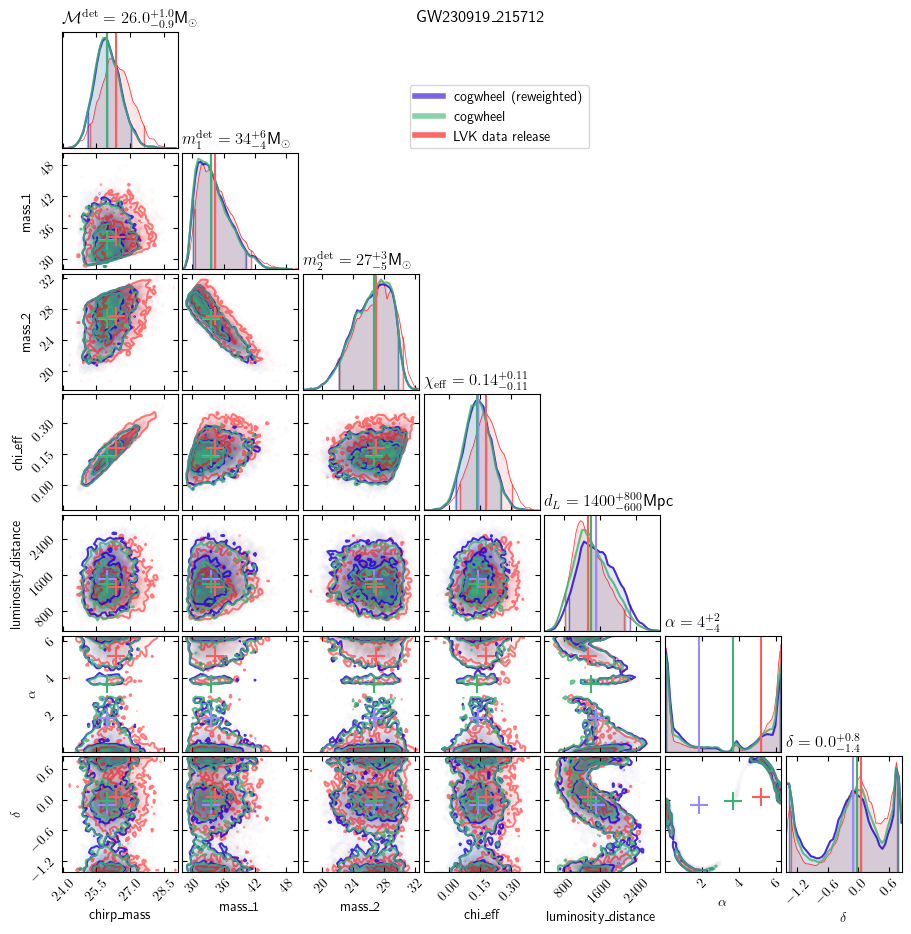

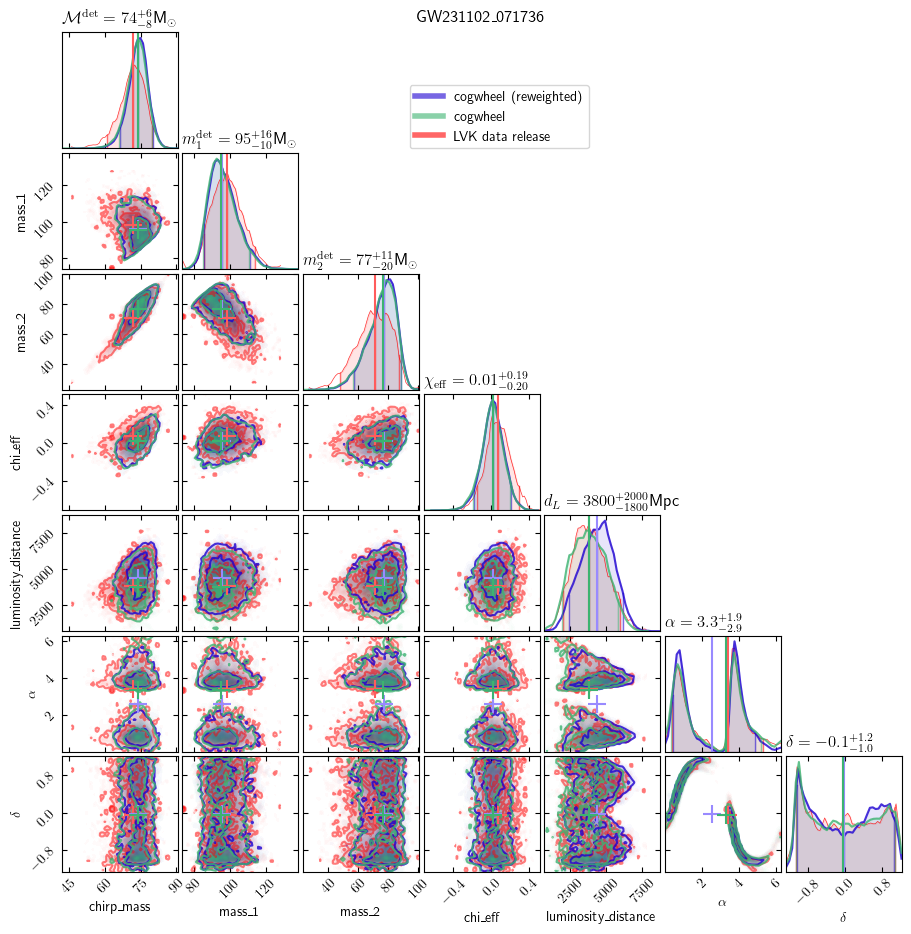

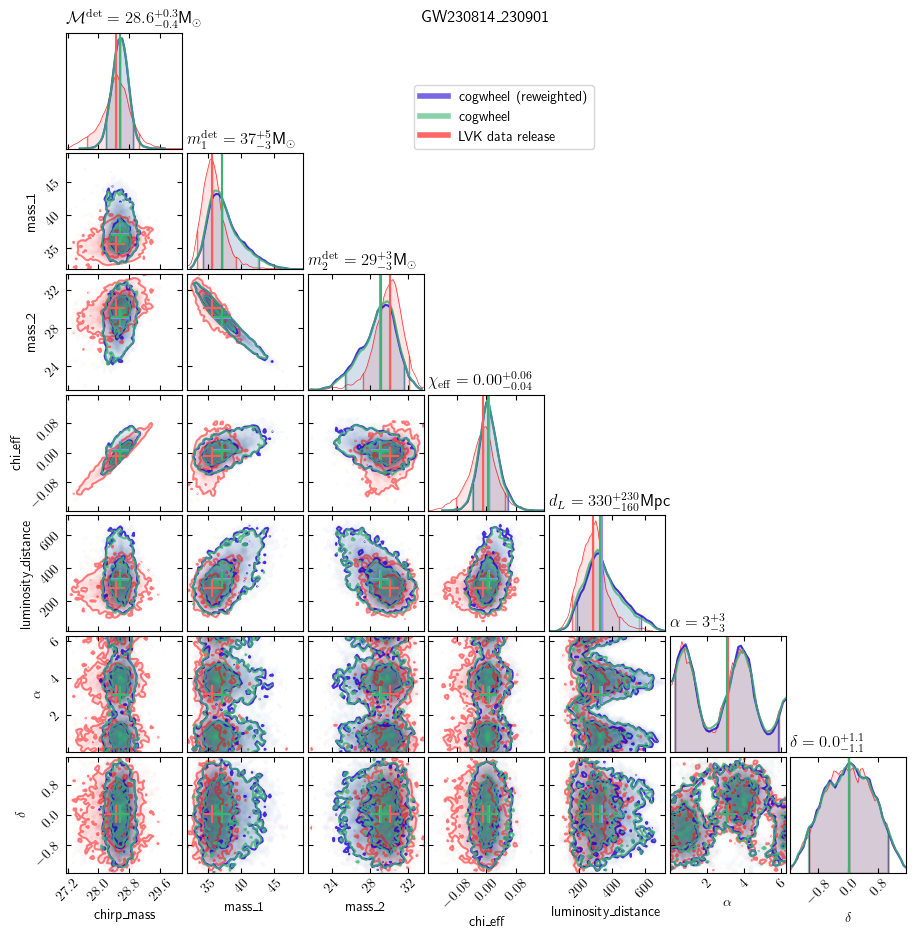

In [15]:
for eventname, event_path in zip(eventname_list, event_dir_list):
    samples, samples_lvk = load_posterior_samples(eventname, event_path)

    # add reweights from luminosity distance priors
    reweights_name = 'weights_dl'
    add_reweights(samples, reweights_name)

    # get the subset of the data release posterior parameters
    lvk_samples_to_plot = {}
    for key, value in samples_lvk.items():
        if key in plot_params_lvk:
            lvk_samples_to_plot[key] = value

    # PLOT #
    corner_plot_lvk = cogwheel.gw_plotting.CornerPlot(
        pd.DataFrame.from_dict(lvk_samples_to_plot), params=plot_params_lvk, tail_probability=1e-4,
        color_2d=c2, kwargs_1d=dict(color=c2, alpha=0.8, linewidth=0.5), contour_kwargs=dict(alpha=0.5)
    )
    corner_plot = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d=c1,
        kwargs_1d=dict(color=c1, alpha=0.8), contour_kwargs=dict(alpha=0.8)
    )
    corner_plot_rw = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d=c3,
        kwargs_1d=dict(color=c3, alpha=0.8), contour_kwargs=dict(alpha=0.8), weights_col=reweights_name
    )
    corner_plot_lvk.plot()
    corner_plot.plot(fig=corner_plot_lvk.fig, title=eventname)
    corner_plot_rw.plot(fig=corner_plot_lvk.fig, title=eventname)
    
    # scatter the median values
    medians_lvk = get_medians(lvk_samples_to_plot, corner_plot_lvk)
    medians = get_medians(samples, corner_plot)
    medians_rw = get_medians(samples, corner_plot_rw)
    
    corner_plot_lvk.scatter_points(medians_lvk, colors=['#FF5C5C'], s=150,
                               zorder=2, marker='+', adjust_lims=True)
    corner_plot.scatter_points(medians, colors=['#998AFF'], s=150,
                               zorder=2, marker='+', adjust_lims=True)
    corner_plot_rw.scatter_points(medians_rw, colors=[c3], s=150,
                               zorder=2, marker='+', adjust_lims=True)
    
    corner_plot_lvk.axes[0,0].legend(custom_lines, ['cogwheel (reweighted)', 'cogwheel', 'LVK data release'], loc=(3.,0.))

In [ ]:
# colors for plotting
c1 = '#1C00D1'
c2 = '#FF0000'

# do we want to overplot the posteriors from the LIGO data release?
plot_dr_data = True

# check out the posteriors for the other events
for idx, eventname in enumerate(eventname_list):

    if eventname == 'GW230627_015337':
        continue # !! hacky

    # find the "earliest" run with posterior samples
    i = 0
    while i < 10:
        try:
            samples = pd.read_feather(os.path.join(event_dir_list[idx], f'run_{i}', 'samples.feather'))
            print(f"loaded posterior samples for {eventname} run {i}")
            break
        except FileNotFoundError:
            i += 1
            samples = None
    if samples is None:
        print(f"no posterior samples found for {eventname}! continuing to next event.")
        continue

    # load the posterior samples from the LIGO PE data release
    if plot_dr_data:
        pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
        data = read(pe_data_fn)
        # get the posterior samples using the IMRPhenomXPHM approximant
        posterior_samples_dr = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]
    
        # get the subset of the data release posterior parameters
        dr_samples_to_plot = {}
        for key, value in posterior_samples_dr.items():
            if key in plot_params_dr:
                dr_samples_to_plot[key] = value
        
        corner_plot_dr = cogwheel.gw_plotting.CornerPlot(
            pd.DataFrame.from_dict(dr_samples_to_plot), params=plot_params_dr, tail_probability=1e-4,
            color_2d=c2, kwargs_1d=dict(color=c2, alpha=0.8, linewidth=0.5), contour_kwargs=dict(alpha=0.5, linewidths=0.5)
        )
        
        corner_plot_dr.plot(title=eventname)
        medians_dr = {}
        for key, value in dr_samples_to_plot.items():
            medians_dr[key] = corner_plot_dr._get_median_and_central_interval(key)[0]
        corner_plot_dr.scatter_points(medians_dr, colors=['#FF5C5C'], s=120,
                               zorder=2, marker='+', adjust_lims=True)

        # add derived quantities
        add_derived_quantities(samples)
    
        corner_plot = cogwheel.gw_plotting.CornerPlot(
            samples, params=plot_params, tail_probability=1e-4, color_2d=c1,
            kwargs_1d=dict(color=c1, alpha=0.8), contour_kwargs=dict(alpha=0.8)
        )
        corner_plot.plot(fig=corner_plot_dr.fig, title=eventname)
    
        # scatter the median values
        medians = {}
        for key in samples.keys():
            medians[key] = corner_plot._get_median_and_central_interval(key)[0]
        corner_plot.scatter_points(medians, colors=['#998AFF'], s=120,
                                   zorder=2, marker='+', adjust_lims=True)

loaded posterior samples for GW231226_101520 run 1
loaded posterior samples for GW240104_164932 run 0
loaded posterior samples for GW230914_111401 run 0
loaded posterior samples for GW231028_153006 run 0
loaded posterior samples for GW231206_233901 run 0
loaded posterior samples for GW230628_231200 run 0
loaded posterior samples for GW230518_125908 run 0


2025-12-17  18:58:10 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2025-12-17  18:58:10 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2025-12-17  18:58:10 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2025-12-17  18:58:10 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2025-12-17  18:58:10 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Currently only the IMRPhenomNSBH waveform model can be used. Unable to calculate the NSBH conversion
2025-12-17  18:58:10 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Current

loaded posterior samples for GW230927_153832 run 0
loaded posterior samples for GW231123_135430 run 1
loaded posterior samples for GW230919_215712 run 0
loaded posterior samples for GW231102_071736 run 0
loaded posterior samples for GW230814_230901 run 0
